# Iris Flower Classification
## CODSOFT Data Science Internship - Task 3

**Student Name:** Jenil Bhisra  
**Internship:** CODSOFT  
**Domain:** Data Science  
**Task Number:** 3  
**Project:** Iris Flower Classification

---

## 1. Project Objective

The objective of this project is to build a machine learning model that can classify Iris flowers into their correct species using flower measurements.

The Iris dataset contains measurements of three flower species:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

Each flower has four important measurements:

- Sepal length
- Sepal width
- Petal length
- Petal width

This is a supervised machine learning classification problem because the model learns from already labelled flower species and then predicts the species of new flowers.

## 2. Import Required Libraries

In this section, we import all required Python libraries for data analysis, visualization, preprocessing, model building, and evaluation.

In [ ]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Load Dataset

The dataset file used in this project is `IRIS.csv`.  
Make sure this CSV file is in the same folder as this notebook before running the notebook.

In [ ]:
# Load the Iris dataset

file_path = 'IRIS.csv'
df = pd.read_csv(file_path)

# Display first five rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 4. Dataset Overview

Now we check the size, column names, data types, missing values, and basic statistical summary of the dataset.

In [ ]:
# Shape of the dataset
print("Dataset shape:", df.shape)

# Column names
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (150, 5)

Column names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
# Statistical summary
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
# Check missing values
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [ ]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 3


### Dataset Observation

The dataset contains 150 records and 5 columns.  
There are four numerical feature columns and one target column named `species`.

The target column contains the species name of each Iris flower. This is the value that our machine learning model will learn to predict.

## 5. Data Cleaning

Before training a machine learning model, it is important to clean the dataset.

In this dataset, we check:

- Missing values
- Duplicate records
- Correct column names
- Correct target column

In [ ]:
# Remove duplicate rows if any
df = df.drop_duplicates()

# Check missing values again
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDataset shape after cleaning:", df.shape)

Missing values after cleaning:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Dataset shape after cleaning: (147, 5)


## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand patterns in the data using graphs and statistics.

### 6.1 Species Distribution

This graph shows how many samples are available for each Iris species.

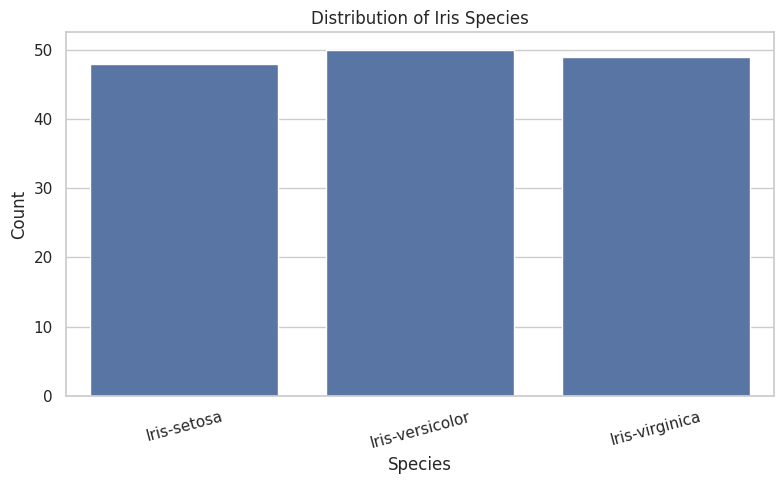

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='species')
plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Observation

The dataset is almost balanced because each species has nearly the same number of records.  
Balanced data is useful because the model gets equal learning examples for each class.

### 6.2 Sepal Length by Species

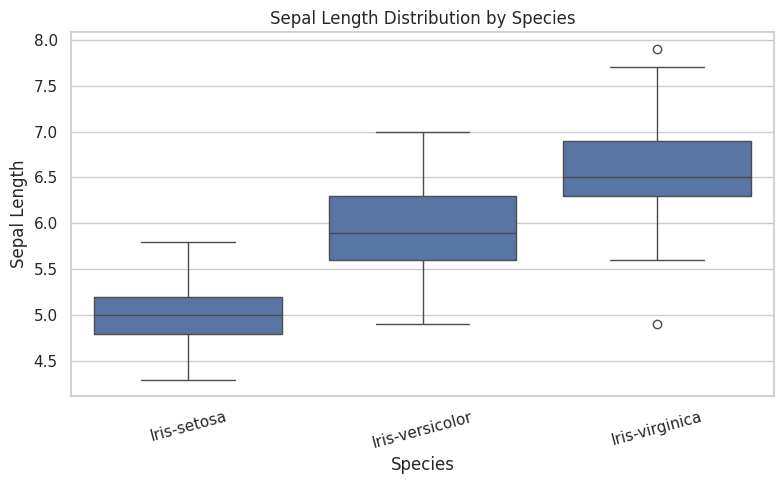

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='species', y='sepal_length')
plt.title('Sepal Length Distribution by Species')
plt.xlabel('Species')
plt.ylabel('Sepal Length')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Observation

Sepal length varies among the species, but there is some overlap between versicolor and virginica.  
This means sepal length alone may not be enough for perfect classification.

### 6.3 Sepal Width by Species

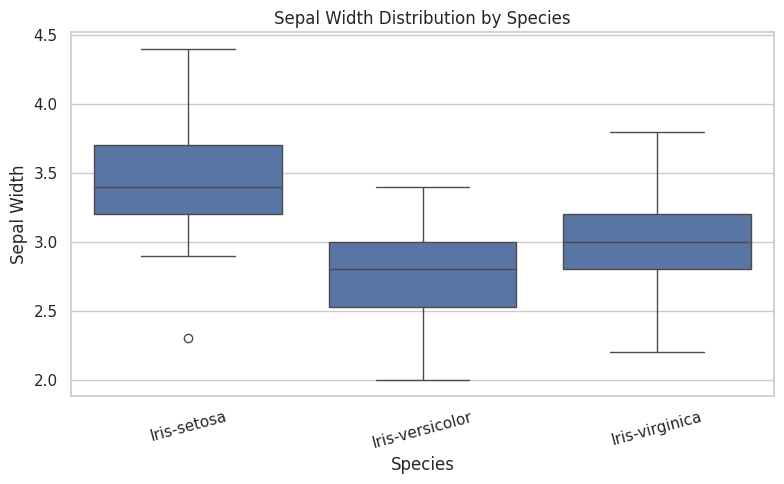

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='species', y='sepal_width')
plt.title('Sepal Width Distribution by Species')
plt.xlabel('Species')
plt.ylabel('Sepal Width')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Observation

Sepal width shows variation across species, but it also has overlap.  
It can help the model, but it may not be the strongest feature.

### 6.4 Petal Length by Species

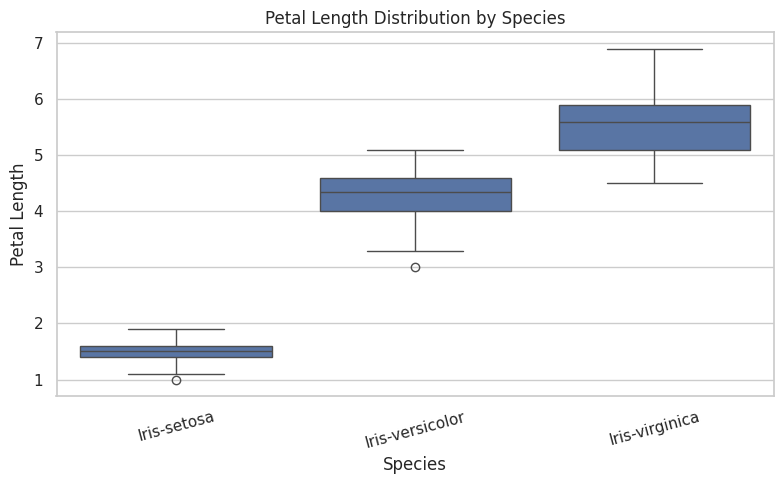

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='species', y='petal_length')
plt.title('Petal Length Distribution by Species')
plt.xlabel('Species')
plt.ylabel('Petal Length')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Observation

Petal length clearly separates Iris-setosa from the other two species.  
This is one of the most important features for classification.

### 6.5 Petal Width by Species

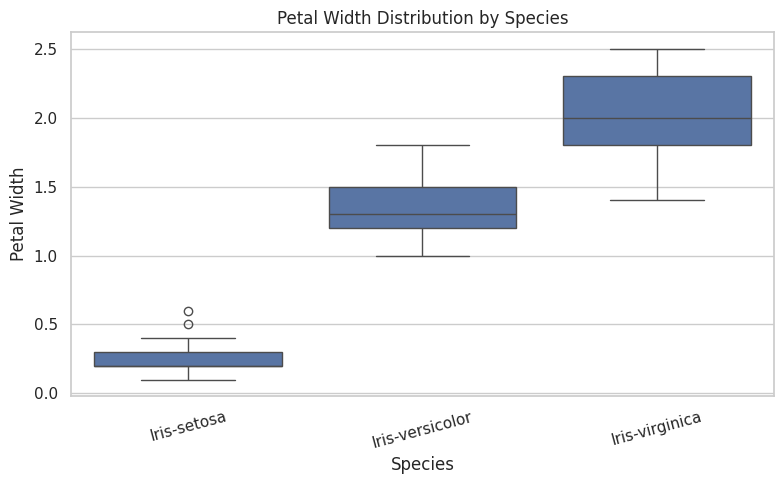

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='species', y='petal_width')
plt.title('Petal Width Distribution by Species')
plt.xlabel('Species')
plt.ylabel('Petal Width')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Observation

Petal width is also highly useful because the species have different petal width ranges.  
Petal measurements are stronger indicators than sepal measurements.

### 6.6 Pairplot

A pairplot helps us compare relationships between all numerical features.

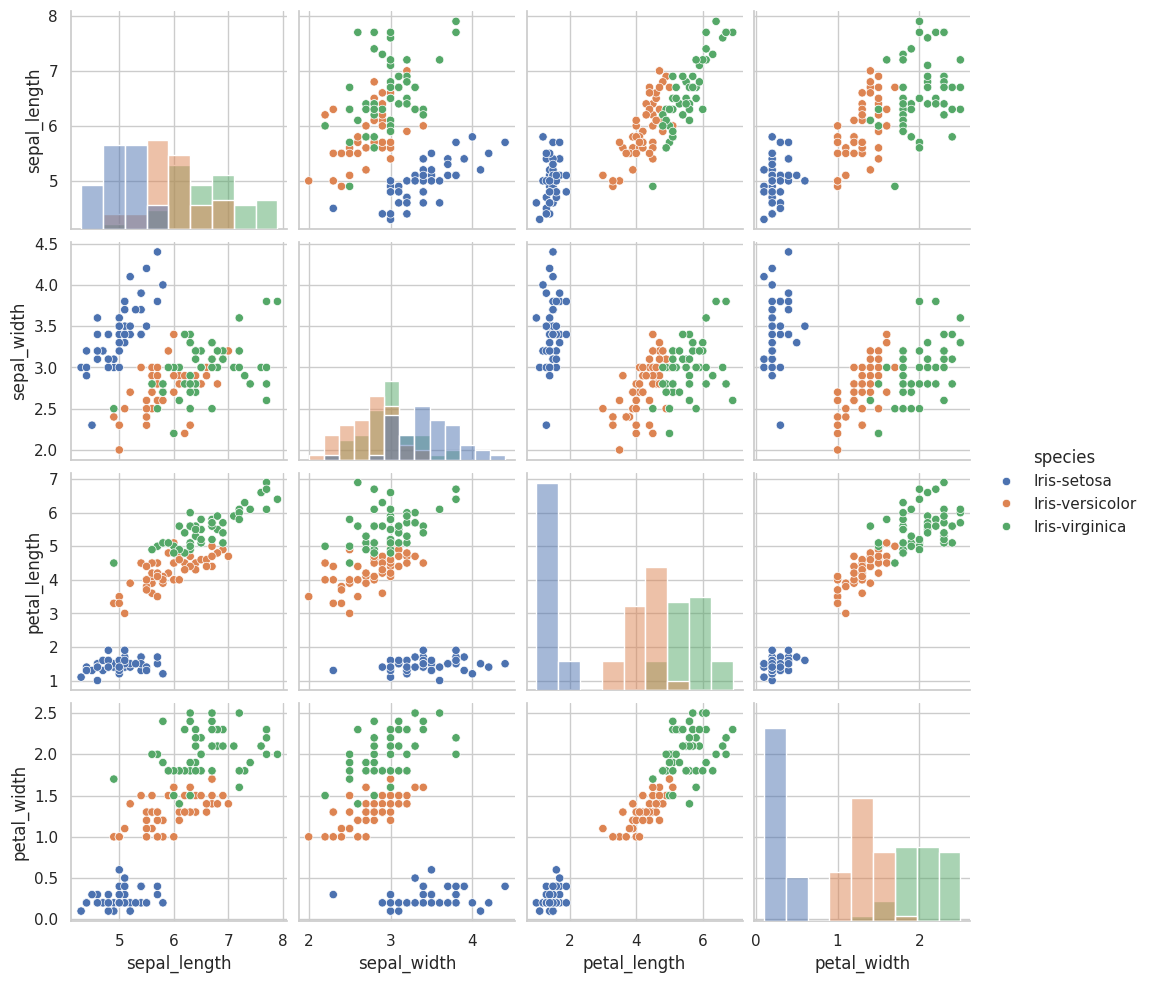

In [ ]:
sns.pairplot(df, hue='species', diag_kind='hist')
plt.show()

### Observation

The pairplot shows that Iris-setosa is clearly separated from the other species.  
Iris-versicolor and Iris-virginica have some overlap, but petal length and petal width still help distinguish them.

### 6.7 Correlation Heatmap

The heatmap shows relationships between numerical features.

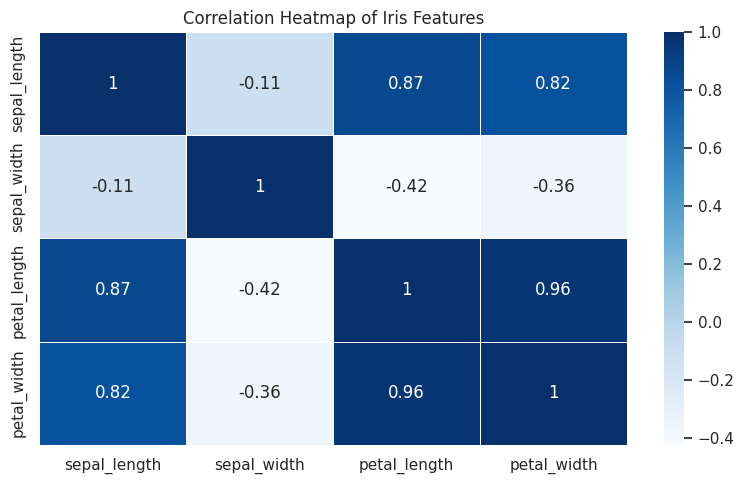

In [ ]:
plt.figure(figsize=(8,5))
corr = df.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='Blues', linewidths=0.5)
plt.title('Correlation Heatmap of Iris Features')
plt.tight_layout()
plt.show()

### Observation

Petal length and petal width are strongly correlated.  
This means flowers with larger petal length usually also have larger petal width.

## 7. Data Preprocessing

Machine learning models need numerical data.  
The feature columns are already numerical, but the target column `species` contains text labels.  
So we convert species names into numeric labels using Label Encoding.

In [ ]:
# Encode target labels

label_encoder = LabelEncoder()
df['species_encoded'] = label_encoder.fit_transform(df['species'])

# Display class mapping
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Class mapping:")
print(class_mapping)

df.head()

Class mapping:
{'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


,sepal_length,sepal_width,petal_length,petal_width,species,species_encoded
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


## 8. Feature Selection

We use the four flower measurements as input features and the encoded species column as the target variable.

In [ ]:
# Define features and target

X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species_encoded']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (147, 4)
Target shape: (147,)


## 9. Train-Test Split

The dataset is divided into training and testing data.

- Training data is used to train the model.
- Testing data is used to evaluate model performance.

We use `stratify=y` to keep the same species distribution in both training and testing sets.

In [ ]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (117, 4)
Testing features: (30, 4)
Training target: (117,)
Testing target: (30,)


## 10. Feature Scaling

Feature scaling standardizes numerical values.  
Logistic Regression benefits from scaling, while tree-based models can also work without scaling.

Here, we scale all features for consistency.

In [ ]:
# Scale the feature values

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


## 11. Model Building

We train three classification models:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

Then we compare their performance using accuracy, precision, recall, and F1-score.

In [ ]:
# Create models

models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate models
results = []

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print("\n", "="*50)
    print(model_name)
    print("="*50)
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))


Logistic Regression
Accuracy: 0.9333
Precision: 0.9333
Recall: 0.9333
F1 Score: 0.9333

Decision Tree
Accuracy: 0.9333
Precision: 0.9333
Recall: 0.9333
F1 Score: 0.9333

Random Forest
Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
F1 Score: 0.9666


## 12. Model Comparison

Now we compare all trained models using a table and graph.

In [ ]:
# Create model comparison dataframe

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,Decision Tree,0.933333,0.933333,0.933333,0.933333
2,Random Forest,0.966667,0.969697,0.966667,0.966583


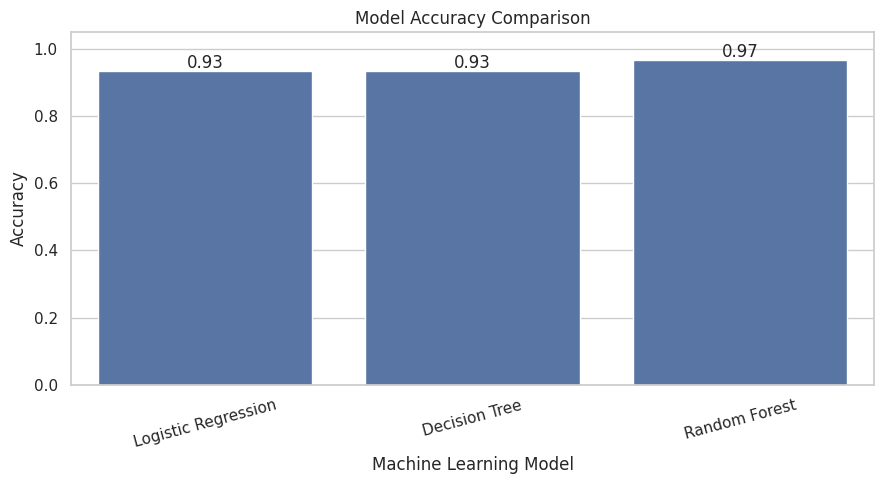

In [ ]:
plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x='Model', y='Accuracy')
plt.title('Model Accuracy Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)

for index, value in enumerate(results_df['Accuracy']):
    plt.text(index, value + 0.01, f"{value:.2f}", ha='center')

plt.tight_layout()
plt.show()

### Observation

The comparison table and bar chart show how well each model performed on the testing data.  
The best model is selected based on the highest accuracy and balanced performance.

## 13. Best Model Selection

In [ ]:
# Select best model based on accuracy

best_model_name = results_df.sort_values(by='Accuracy', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]

print("Best Model:", best_model_name)

# Predict using best model
best_y_pred = best_model.predict(X_test_scaled)

print("\nBest Model Accuracy:", accuracy_score(y_test, best_y_pred))

Best Model: Random Forest

Best Model Accuracy: 0.9666666666666667


### Best Model Explanation

The best model is selected using test accuracy.  
A good model should not only give high accuracy but should also perform well across precision, recall, and F1-score.

For the Iris dataset, machine learning models usually perform very well because the features clearly separate the flower species.

## 14. Confusion Matrix

A confusion matrix shows how many predictions were correct and incorrect for each species.

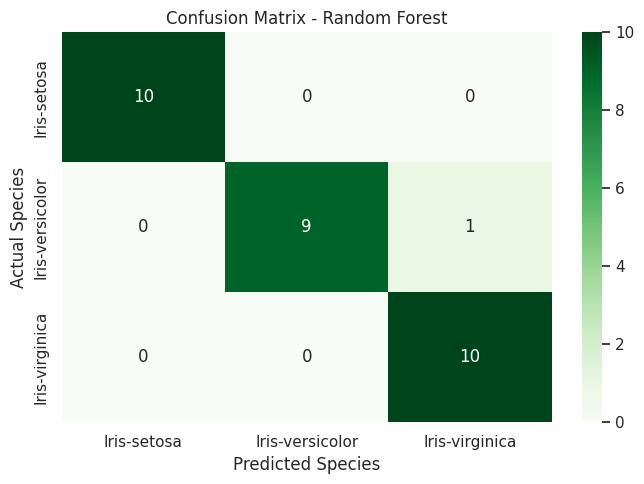

In [ ]:
# Confusion matrix for best model

cm = confusion_matrix(y_test, best_y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.tight_layout()
plt.show()

### Confusion Matrix Explanation

- Correct predictions are shown on the diagonal.
- Values outside the diagonal represent incorrect predictions.
- A strong model will have most values on the diagonal and very few values outside it.

## 15. Classification Report

The classification report shows precision, recall, F1-score, and support for each species.

In [ ]:
print("Classification Report for", best_model_name)
print(classification_report(y_test, best_y_pred, target_names=label_encoder.classes_))

Classification Report for Random Forest
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



### Classification Report Explanation

- **Precision** tells how many predicted species labels were correct.
- **Recall** tells how many actual species were correctly identified.
- **F1-score** is the balance between precision and recall.
- **Support** shows how many samples of each class were present in the test data.

## 16. Sample Prediction

Now we create a sample flower measurement and use the best model to predict its species.

In [ ]:
# Sample flower measurements

sample_flower = pd.DataFrame({
    'sepal_length': [5.1],
    'sepal_width': [3.5],
    'petal_length': [1.4],
    'petal_width': [0.2]
})

# Scale sample data
sample_scaled = scaler.transform(sample_flower)

# Predict species
sample_prediction = best_model.predict(sample_scaled)
predicted_species = label_encoder.inverse_transform(sample_prediction)

print("Sample Flower Measurements:")
print(sample_flower)

print("\nPredicted Iris Species:", predicted_species[0])

Sample Flower Measurements:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2

Predicted Iris Species: Iris-setosa


## 17. Conclusion

In this project:

1. The Iris flower dataset was loaded and explored successfully.
2. The dataset contained flower measurements and species labels.
3. Missing values and duplicate rows were checked during data cleaning.
4. Exploratory Data Analysis was performed using countplot, boxplots, pairplot, and heatmap.
5. Petal length and petal width were found to be very important features.
6. The target species column was converted into numeric form using Label Encoding.
7. The dataset was split into training and testing sets.
8. Feature scaling was applied using StandardScaler.
9. Logistic Regression, Decision Tree, and Random Forest models were trained.
10. The models were compared using accuracy, precision, recall, and F1-score.
11. The best model was selected based on performance.
12. A sample flower prediction was performed successfully.

This project successfully demonstrates how machine learning can classify Iris flowers based on sepal and petal measurements.